In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [ ]:
dataset = load_dataset("microsoft/cats_vs_dogs", split="train")
print("Dataset loaded:", len(dataset), "images")

Dataset loaded: 23410 images


In [ ]:
indices = list(range(len(dataset)))
random.shuffle(indices)

images, labels = [], []
for i in indices[:2500]:
    sample = dataset[i]
    img = sample['image'].resize((224, 224))
    img = np.array(img)
    if img.shape == (224, 224, 3):
        img = img / 255.0
        images.append(img)
        labels.append(sample['labels'])

images = np.array(images)
labels = np.array(labels)
print("Total images:", len(images))

unique, counts = np.unique(labels, return_counts=True)
print("Cat images:", counts[0])
print("Dog images:", counts[1])


Total images: 2497
Cat images: 1249
Dog images: 1248


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42
)
print("Training:", len(X_train), "Testing:", len(X_test))

#-----------------------------------------------------------------------------------------------


#CELL 5 — Build Model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Model ready!")

Training: 1997 Testing: 500
Model ready!


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=16,
    validation_data=(X_test, y_test)
)


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 86s 651ms/step - accuracy: 0.9429 - loss: 0.1697 - val_accuracy: 0.9780 - val_loss: 0.0869
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 630ms/step - accuracy: 0.9710 - loss: 0.0697 - val_accuracy: 0.9720 - val_loss: 0.0748
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 629ms/step - accuracy: 0.9780 - loss: 0.0563 - val_accuracy: 0.9760 - val_loss: 0.0725
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 653ms/step - accuracy: 0.9820 - loss: 0.0460 - val_accuracy: 0.9740 - val_loss: 0.0689
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 632ms/step - accuracy: 0.9875 - loss: 0.0378 - val_accuracy: 0.9720 - val_loss: 0.0674


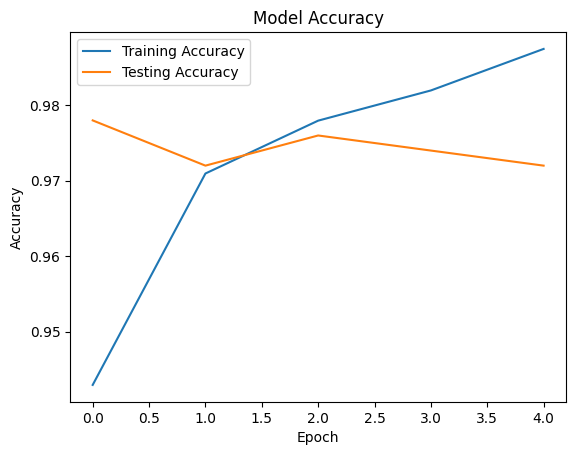

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


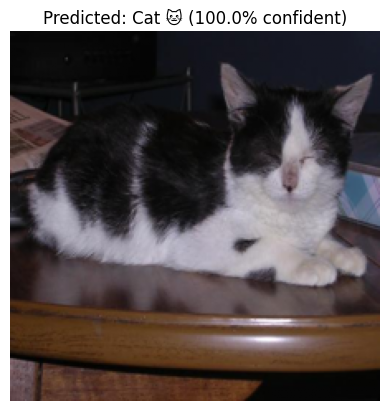

In [ ]:
test_image = X_test[10]
actual_label = y_test[10]

prediction = model.predict(np.expand_dims(test_image, axis=0))[0][0]

plt.imshow(test_image)
plt.axis('off')

dog_confidence = prediction * 100
cat_confidence = (1 - prediction) * 100

if prediction > 0.5:
    plt.title(f"Predicted: Dog 🐶 ({dog_confidence:.1f}% confident)")
else:
    plt.title(f"Predicted: Cat 🐱 ({cat_confidence:.1f}% confident)")

plt.show()

In [ ]:
model.save('dog_cat_model.keras')
print("Model saved!")

Model saved!


In [ ]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.models.load_model('dog_cat_model.keras')

st.title("🐶🐱 Dog vs Cat Classifier")
st.write("Upload a picture and I'll tell you if it's a dog or a cat!")

uploaded_file = st.file_uploader("Choose an image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    img = Image.open(uploaded_file).resize((224, 224))
    st.image(img, caption="Uploaded Image")

    img_array = np.array(img) / 255.0
    prediction = model.predict(np.expand_dims(img_array, axis=0))[0][0]

    dog_confidence = prediction * 100
    cat_confidence = (1 - prediction) * 100

    predicted_label = "Dog 🐶" if prediction > 0.5 else "Cat 🐱"

    st.success(f"Prediction: {predicted_label}")
    st.write(f"Confidence — Cat: {cat_confidence:.1f}% | Dog: {dog_confidence:.1f}%")

Overwriting app.py


In [ ]:
!pip install pyngrok
!pip install streamlit
!streamlit run app.py --server.port 8501 &> streamlit_log.txt &
import time
time.sleep(8)
!cat streamlit_log.txt

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("YOUR_TOKEN_HERE")

!streamlit run app.py &>/dev/null&

public_url = ngrok.connect(8501)
print("Your web app is live at:", public_url)

Your web app is live at: NgrokTunnel: "https://dyslexia-celtic-undercut.ngrok-free.dev" -> "http://localhost:8501"
